# Allstate Claims Severity (EDA)


In [2]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.data.loader import DataLoader
from src.utils.logging_config import setup_logging, get_logger

warnings.filterwarnings('ignore')
setup_logging()
logger = get_logger(__name__)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

In [3]:
loader = DataLoader()
train_df = loader.load_train()
test_df = loader.load_test()

cat_columns = loader.get_categorical_columns(train_df)
cont_columns = loader.get_continuous_columns(train_df)

print(f"{len(cat_columns)} categorical features, {len(cont_columns)} continuous features")

2025-12-16 20:59:39,173 - src.data.loader - INFO - Loaded 188,318 training samples
2025-12-16 20:59:39,579 - src.data.loader - INFO - Loaded 125,546 test samples
116 categorical features, 14 continuous features


In [4]:
display(train_df.head())
print("Data types:")
print(train_df.dtypes.value_counts())

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cat10,cat11,cat12,cat13,cat14,cat15,cat16,cat17,cat18,cat19,cat20,cat21,cat22,cat23,cat24,...,cat107,cat108,cat109,cat110,cat111,cat112,cat113,cat114,cat115,cat116,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,A,B,A,A,A,A,A,A,A,A,A,A,A,B,A,...,J,G,BU,BC,C,AS,S,A,O,LB,0.726300,0.245921,0.187583,0.789639,0.310061,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,B,A,A,A,A,A,A,A,A,A,A,A,A,A,A,...,K,K,BI,CQ,A,AV,BM,A,O,DP,0.330514,0.737068,0.592681,0.614134,0.885834,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,B,B,B,B,A,A,A,A,A,A,A,A,A,A,A,...,F,A,AB,DK,A,C,AF,A,I,GK,0.261841,0.358319,0.484196,0.236924,0.397069,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,B,A,...,K,K,BI,CS,C,N,AE,A,O,DJ,0.321594,0.555782,0.527991,0.373816,0.422268,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,B,A,B,A,A,A,A,A,A,A,A,A,A,B,A,...,G,B,H,C,C,Y,BM,A,K,CK,0.273204,0.159990,0.527991,0.473202,0.704268,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


Data types:
object     116
float64     15
int64        1
Name: count, dtype: int64


## Анализ целевой переменной

In [5]:
target = train_df['loss']
print("Target Variable Stats:")
print(f"Mean: {target.mean()}")
print(f"Std: {target.std()}")
print(f"Min: {target.min()}")
print(f"25%: {target.quantile(0.25)}")
print(f"Median: {target.median()}")
print(f"75%: {target.quantile(0.75)}")
print(f"Max: {target.max()}")
print(f"Skewness: {target.skew()}")
print(f"Kurtosis: {target.kurtosis()}")

print("\n\n\n")

# Outlier analysis using IQR method
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target[(target < lower_bound) | (target > upper_bound)]

print(f"Outlier Analysis (IQR method):")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)} ({100*len(outliers)/len(target):.2f}%)")

Target Variable Stats:
Mean: 3037.3376856699833
Std: 2904.086186390403
Min: 0.67
25%: 1204.46
Median: 2115.5699999999997
75%: 3864.045
Max: 121012.25
Skewness: 3.7949583775378586
Kurtosis: 48.079567825418415




Outlier Analysis (IQR method):
Lower bound: -2784.9175
Upper bound: 7853.422500000001
Number of outliers: 11554 (6.14%)


In [6]:
target_log = np.log1p(target)

print("Log-transformed Target Variable Stats:")
print(f"Mean: {target_log.mean()}")
print(f"Std: {target_log.std()}")
print(f"Skewness: {target_log.skew()}")
print(f"Kurtosis: {target_log.kurtosis()}")


Log-transformed Target Variable Stats:
Mean: 7.685907513651466
Std: 0.811309382183691
Skewness: 0.09661958950314063
Kurtosis: -0.14147018368009645


### 2.2 Target Variable Visualization


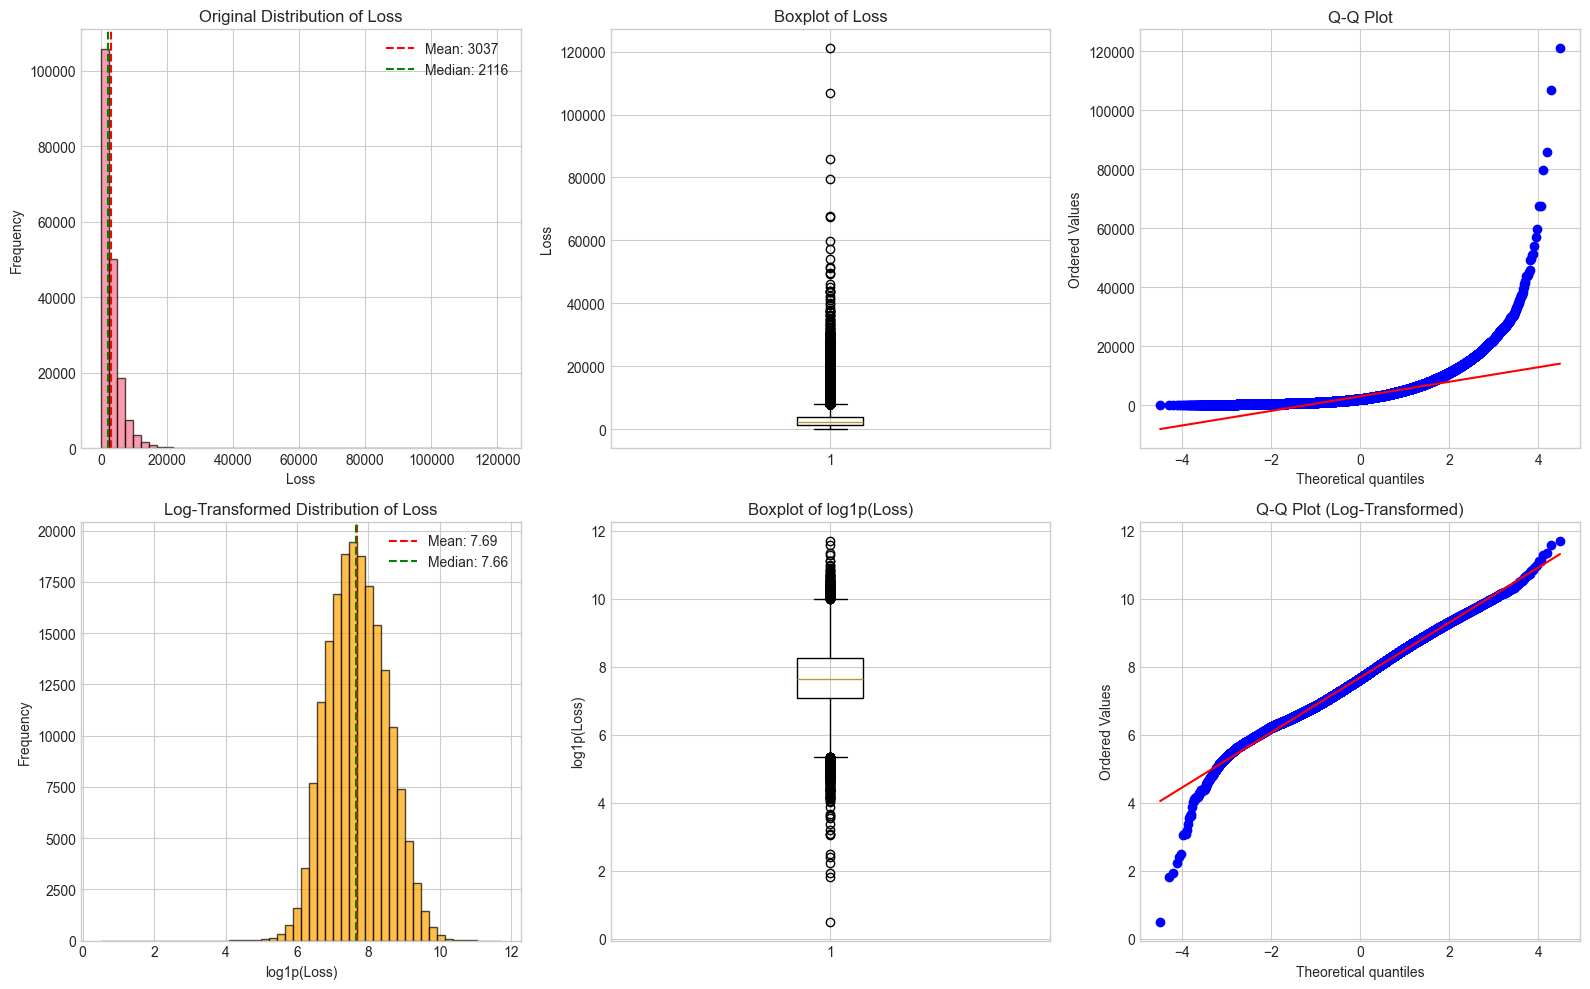

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(target, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(target.mean(), color='red', linestyle='--', label=f'Mean: {target.mean():.0f}')
axes[0, 0].axvline(target.median(), color='green', linestyle='--', label=f'Median: {target.median():.0f}')
axes[0, 0].set_xlabel('Loss')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Original Distribution of Loss')
axes[0, 0].legend()

axes[0, 1].boxplot(target, vert=True)
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Boxplot of Loss')

stats.probplot(target, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot')

axes[1, 0].hist(target_log, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].axvline(target_log.mean(), color='red', linestyle='--', label=f'Mean: {target_log.mean():.2f}')
axes[1, 0].axvline(target_log.median(), color='green', linestyle='--', label=f'Median: {target_log.median():.2f}')
axes[1, 0].set_xlabel('log1p(Loss)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Log-Transformed Distribution of Loss')
axes[1, 0].legend()

axes[1, 1].boxplot(target_log, vert=True)
axes[1, 1].set_ylabel('log1p(Loss)')
axes[1, 1].set_title('Boxplot of log1p(Loss)')

stats.probplot(target_log, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Q-Q Plot (Log-Transformed)')

plt.tight_layout()
plt.show()


## Анализ признаков

In [8]:
cat_cardinality = pd.DataFrame({
    'Feature': cat_columns,
    'Unique Values': [train_df[col].nunique() for col in cat_columns],
    'Most Common': [train_df[col].mode()[0] for col in cat_columns],
    'Most Common %': [100 * train_df[col].value_counts().iloc[0] / len(train_df) for col in cat_columns]
}).sort_values('Unique Values', ascending=False)

print("Categorical Feature Cardinality:")
print(cat_cardinality.to_string(index=False))


Categorical Feature Cardinality:
Feature  Unique Values Most Common  Most Common %
 cat116            326          HK      11.183742
 cat110            131          CL      13.437377
 cat109             84          BI      81.202009
 cat113             61          BM      13.907858
 cat112             51           E      13.354008
 cat115             23           K      23.293578
 cat107             20           F      25.122399
 cat105             20           E      40.619059
 cat101             19           A      56.670632
 cat114             19           A      69.931180
 cat106             17           G      25.045402
 cat104             17           E      22.793891
 cat111             16           A      68.179887
  cat99             16           P      42.191931
 cat100             15           F      22.817787
 cat103             13           A      65.706411
 cat108             11           B      34.787965
 cat102              9           A      94.135452
  cat89          

In [9]:
cont_stats = train_df[cont_columns].describe().T
cont_stats['skewness'] = train_df[cont_columns].skew()
cont_stats['kurtosis'] = train_df[cont_columns].kurtosis()

print("Continuous Feature Statistics:")
print(cont_stats.round(4).to_string())


Continuous Feature Statistics:
           count    mean     std     min     25%     50%     75%     max  skewness  kurtosis
cont1   188318.0  0.4939  0.1876  0.0000  0.3461  0.4758  0.6239  0.9850    0.5164   -0.1017
cont2   188318.0  0.5072  0.2072  0.0011  0.3583  0.5558  0.6818  0.8627   -0.3109   -0.8957
cont3   188318.0  0.4989  0.2021  0.0026  0.3370  0.5280  0.6342  0.9443   -0.0100   -0.6066
cont4   188318.0  0.4918  0.2113  0.1769  0.3274  0.4529  0.6521  0.9543    0.4161   -0.9654
cont5   188318.0  0.4874  0.2090  0.2811  0.2811  0.4223  0.6433  0.9837    0.6816   -0.8769
cont6   188318.0  0.4909  0.2053  0.0127  0.3361  0.4409  0.6550  0.9972    0.4612   -0.7605
cont7   188318.0  0.4850  0.1785  0.0695  0.3502  0.4383  0.5910  1.0000    0.8261    0.0501
cont8   188318.0  0.4864  0.1994  0.2369  0.3128  0.4411  0.6236  0.9802    0.6766   -0.5421
cont9   188318.0  0.4855  0.1817  0.0001  0.3590  0.4414  0.5668  0.9954    1.0724    0.5639
cont10  188318.0  0.4981  0.1859  0.000

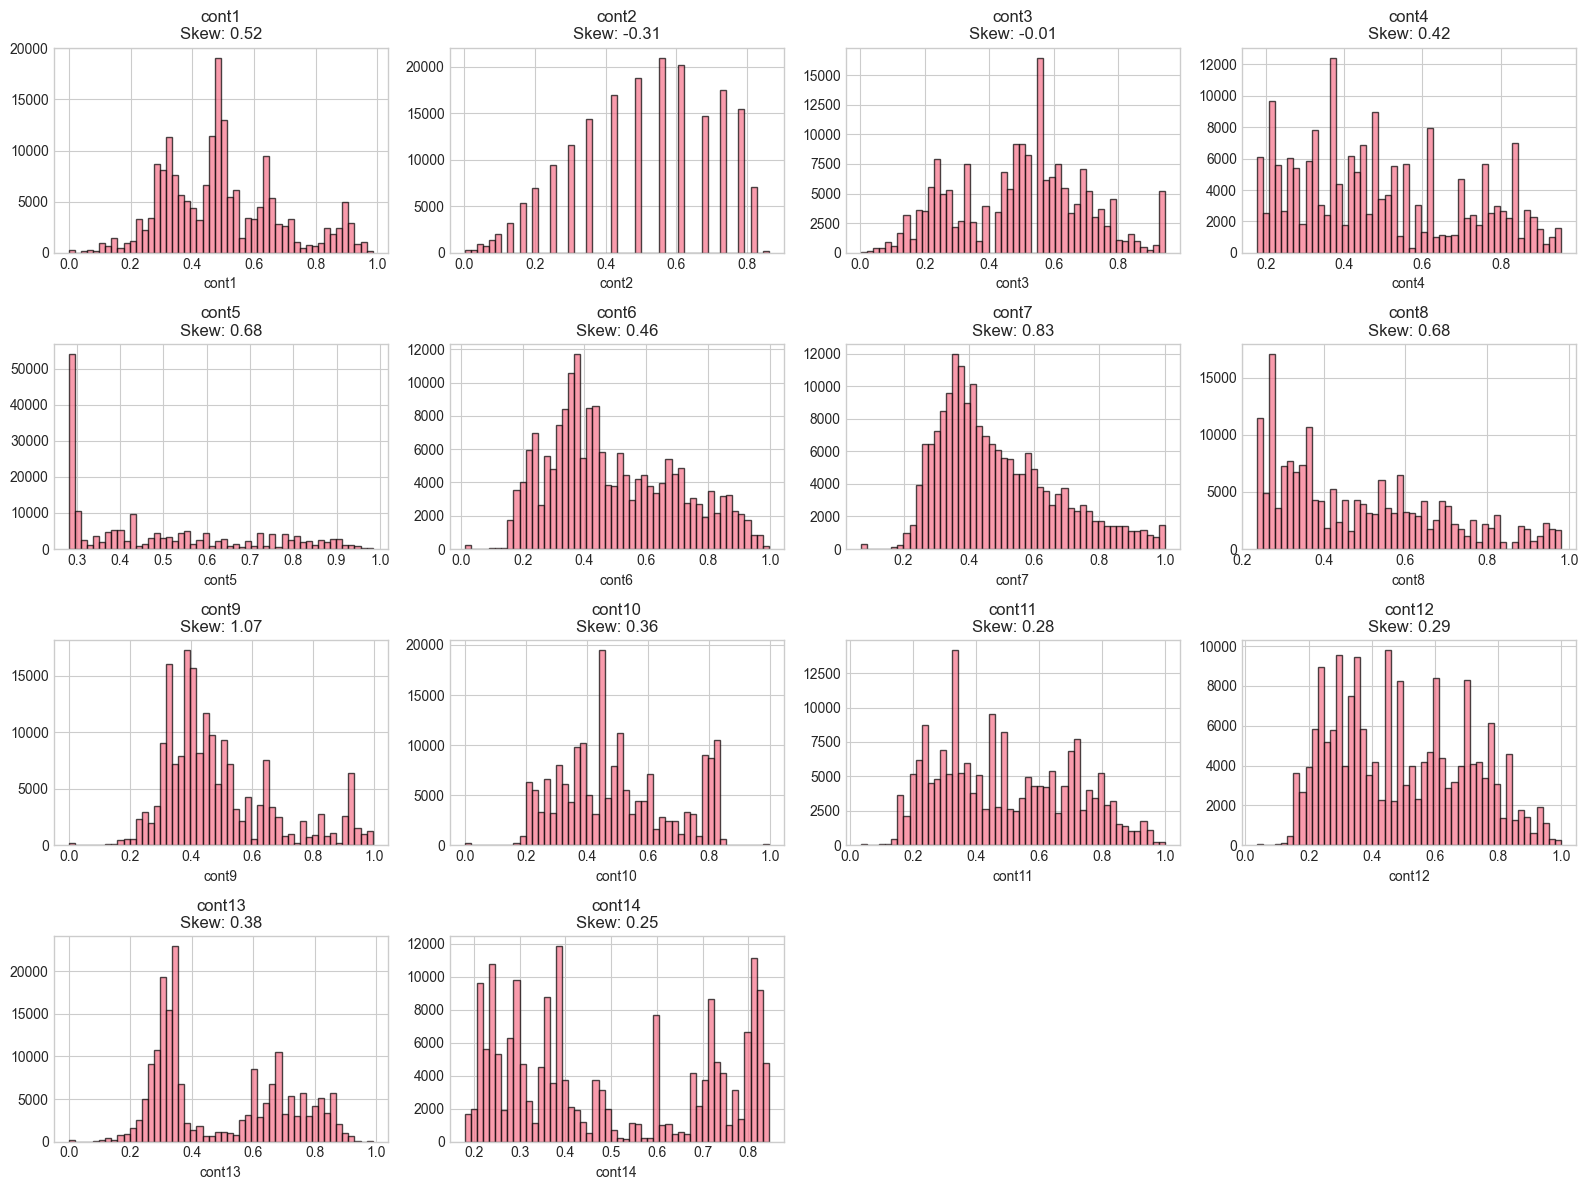

In [10]:
n_cont = len(cont_columns)
n_cols = 4
n_rows = (n_cont + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(cont_columns):
    axes[idx].hist(train_df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}\nSkew: {train_df[col].skew():.2f}')
    axes[idx].set_xlabel(col)
    
for idx in range(n_cont, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


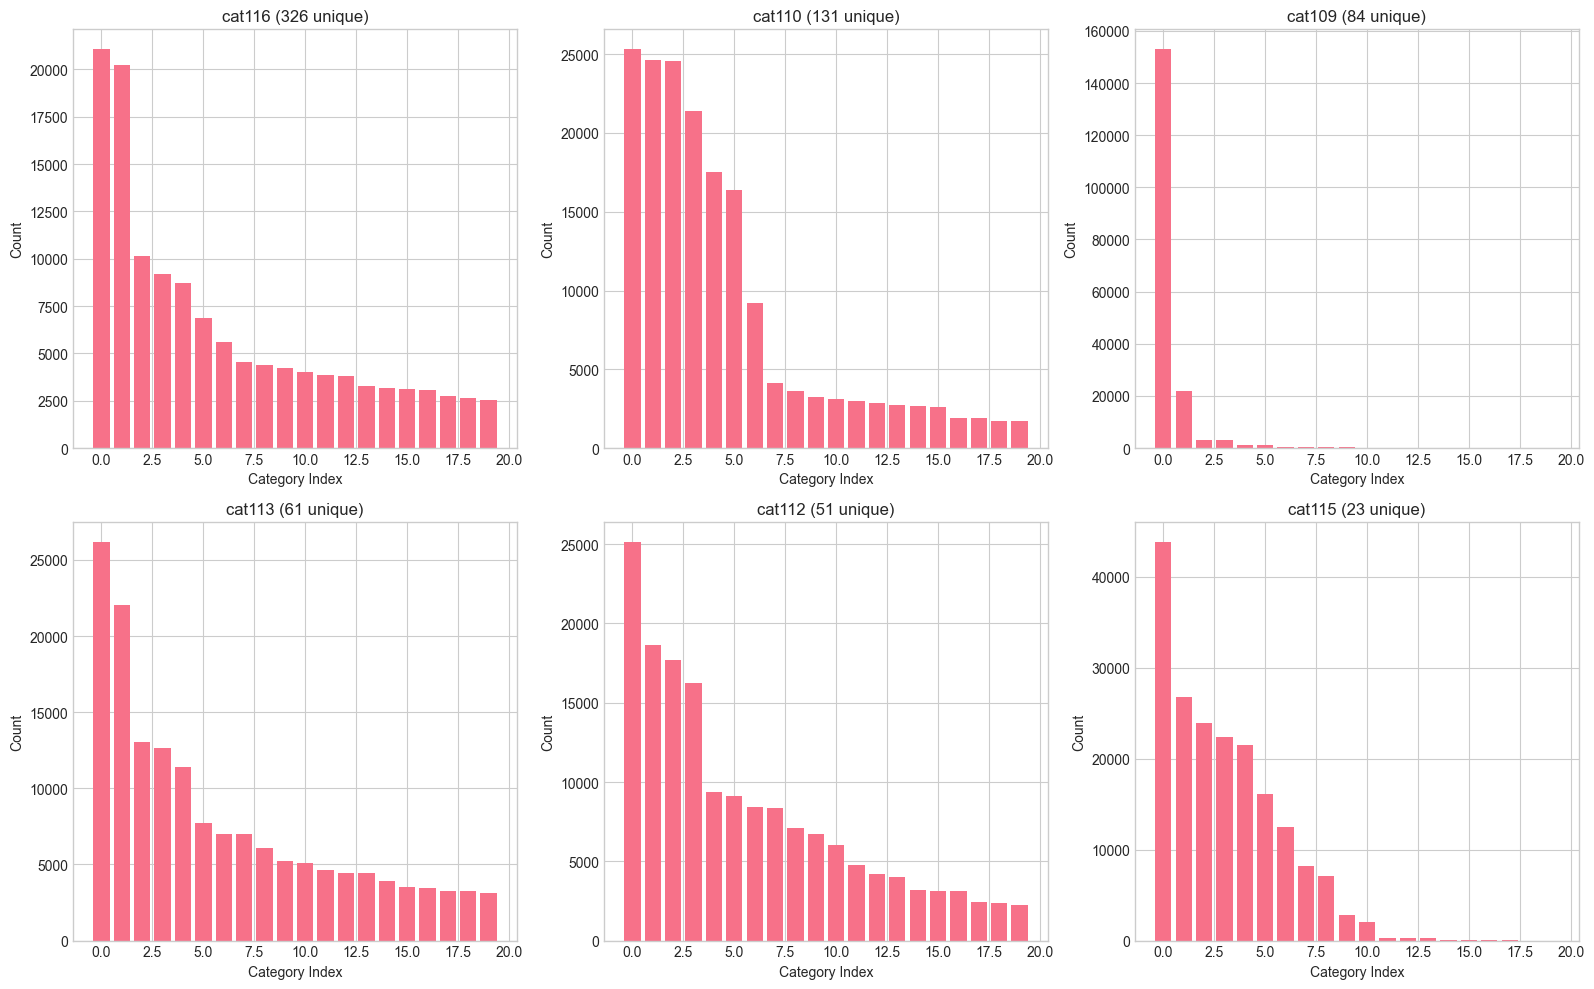

In [11]:
# Plot distributions of top 6 categorical features
top_cats = cat_cardinality.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(top_cats):
    value_counts = train_df[col].value_counts().head(20)
    axes[idx].bar(range(len(value_counts)), value_counts.values)
    axes[idx].set_title(f'{col} ({train_df[col].nunique()} unique)')
    axes[idx].set_xlabel('Category Index')
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [12]:
# Outlier detection for continuous features

def detect_outliers_iqr(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers, 100 * outliers / len(series)

outlier_summary = []
for col in cont_columns:
    n_outliers, pct_outliers = detect_outliers_iqr(train_df[col])
    outlier_summary.append({
        'Feature': col,
        'Outliers': n_outliers,
        'Outlier %': round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print("Outlier Summary (IQR method):")
print(outlier_df.to_string(index=False))


Outlier Summary (IQR method):
Feature  Outliers  Outlier %
  cont9     13194       7.01
  cont7      2659       1.41
 cont10       140       0.07
  cont1         0       0.00
  cont2         0       0.00
  cont3         0       0.00
  cont4         0       0.00
  cont5         0       0.00
  cont6         0       0.00
  cont8         0       0.00
 cont11         0       0.00
 cont12         0       0.00
 cont13         0       0.00
 cont14         0       0.00


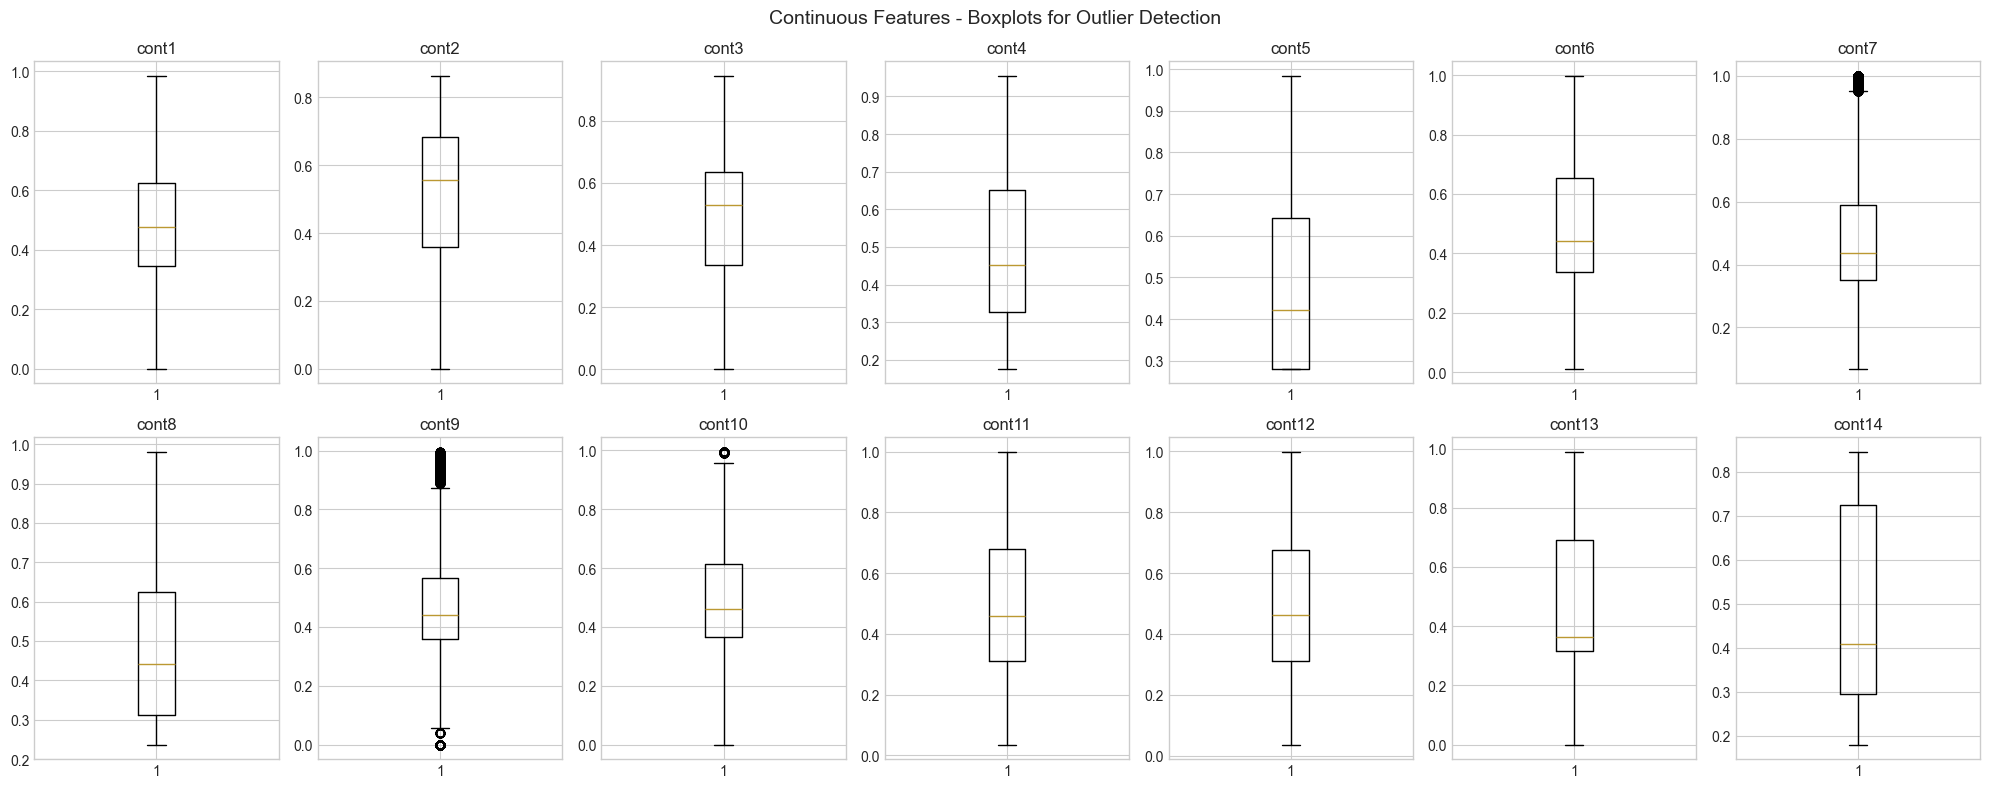

In [13]:
# Boxplots for continuous features to visualize outliers
fig, axes = plt.subplots(2, 7, figsize=(20, 8))
axes = axes.flatten()

for idx, col in enumerate(cont_columns):
    axes[idx].boxplot(train_df[col])
    axes[idx].set_title(col)

plt.suptitle('Continuous Features - Boxplots for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

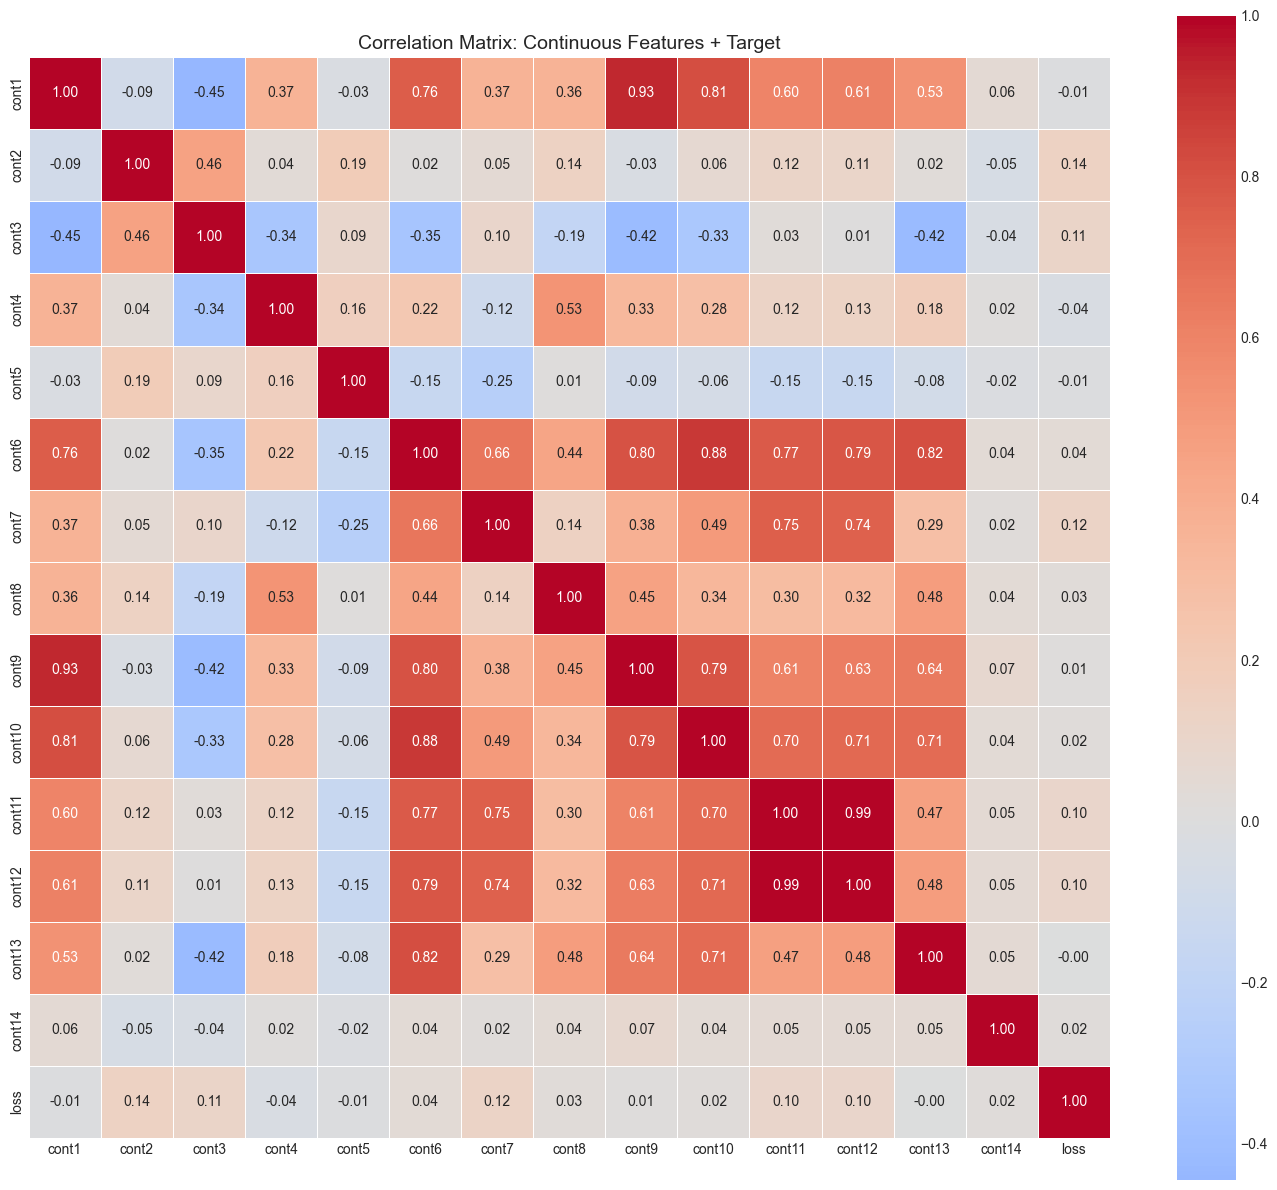

In [14]:
# Correlation matrix for continuous features
cont_data = train_df[cont_columns + ['loss']]
correlation_matrix = cont_data.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix: Continuous Features + Target', fontsize=14)
plt.tight_layout()
plt.show()


In [15]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

X_mi = train_df.drop(columns=['id', 'loss']).copy()
y_mi = train_df['loss'].values

for col in cat_columns:
    le = LabelEncoder()
    X_mi[col] = le.fit_transform(X_mi[col].astype(str))

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_importance = pd.DataFrame({
    'Feature': X_mi.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print(mi_importance.to_string(index=False))

Feature  MI Score
  cat80  0.139866
  cat79  0.099512
 cat101  0.083372
 cat100  0.081340
  cat87  0.063841
  cat12  0.062917
  cat10  0.047588
  cat81  0.045805
   cat1  0.040932
 cat114  0.037411
   cat2  0.035062
   cat9  0.031150
  cat72  0.030760
  cat11  0.029740
  cat13  0.028179
  cat57  0.028023
   cat7  0.023638
  cat89  0.023613
 cat103  0.022141
 cat111  0.020637
   cat3  0.020602
  cat16  0.020494
  cat90  0.020420
  cont2  0.020045
  cat73  0.018764
 cont12  0.018481
 cont14  0.017252
 cont11  0.016846
   cat6  0.016645
  cat50  0.016377
  cat23  0.016322
  cont9  0.015536
  cat36  0.015447
 cat112  0.014407
  cat82  0.014301
 cont13  0.014268
 cat116  0.014000
  cont6  0.012525
  cont1  0.012112
 cont10  0.011966
  cat91  0.011851
  cont7  0.011229
 cat110  0.010335
 cat113  0.010280
  cont3  0.010068
  cat38  0.009991
   cat4  0.009812
   cat5  0.009563
  cont4  0.009562
  cat94  0.008707
  cat40  0.008595
  cat28  0.008396
 cat109  0.007853
  cat25  0.007286
  cat76  0

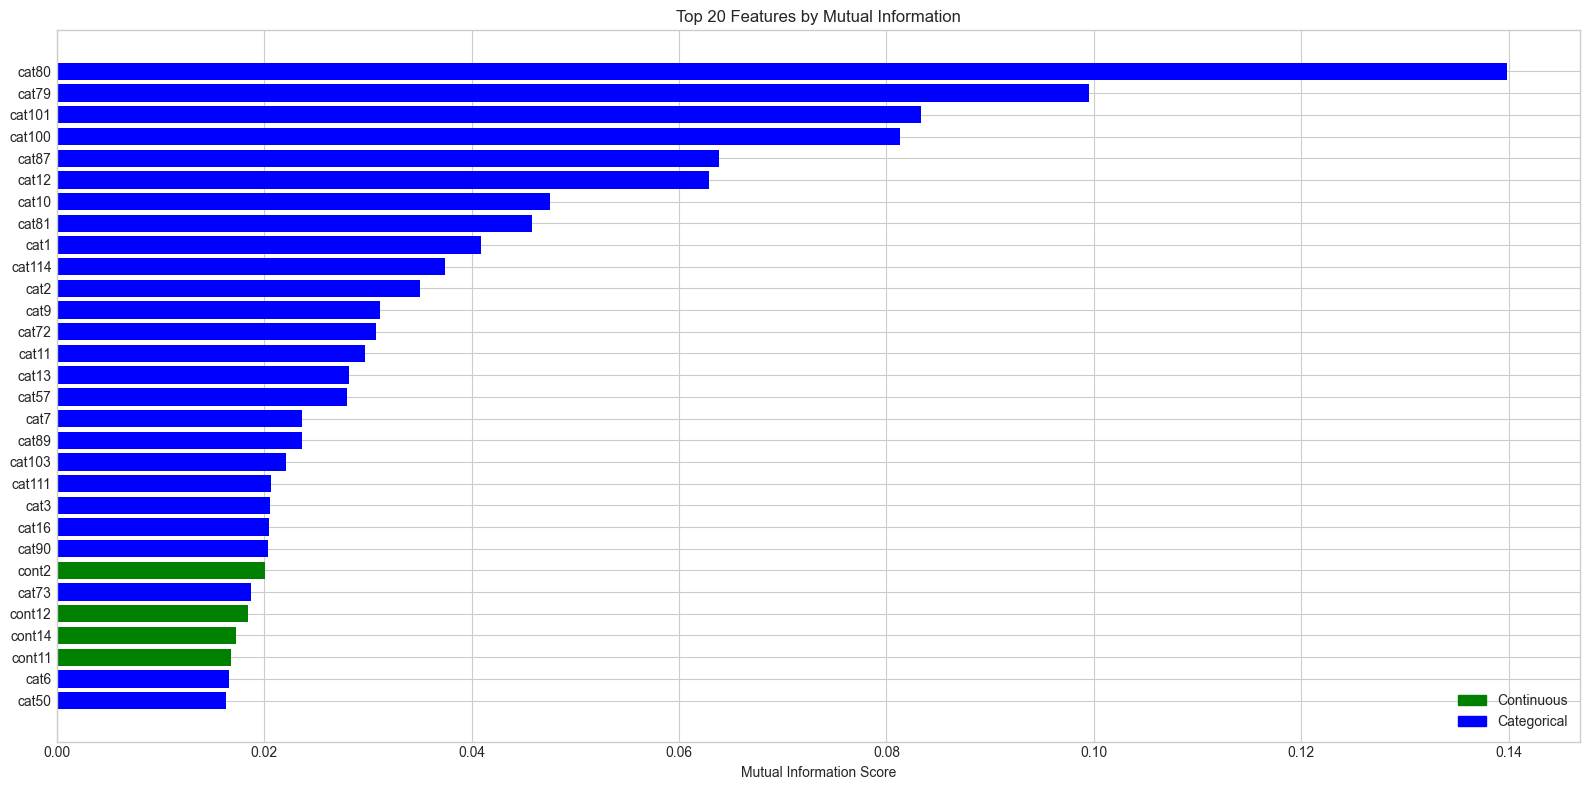

In [16]:
# Visualize feature importance
plt.figure(figsize=(16, 8))

# Top 30 features by MI
top_30 = mi_importance.head(30)
colors = ['green' if f.startswith('cont') else 'blue' for f in top_30['Feature']]
plt.barh(range(len(top_30)), top_30['MI Score'].values, color=colors)
plt.yticks(range(len(top_30)), top_30['Feature'].values)
plt.gca().invert_yaxis()
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information')
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='green', label='Continuous'),
    plt.Rectangle((0,0),1,1, color='blue', label='Categorical')
])

plt.tight_layout()
plt.show()


In [18]:
from src.features.eda_insights import save_eda_insights

max_outlier_pct = outlier_df['Outlier %'].max()
max_cardinality = cat_cardinality['Unique Values'].max()

eda_insights = {
    "target_skewness": float(target.skew()),
    "target_log_skewness": float(target_log.skew()),
    "use_log_target": bool(abs(target.skew()) > 1.0),
    "n_categorical": len(cat_columns),
    "n_continuous": len(cont_columns),
    "max_cardinality": int(max_cardinality),
    "max_outlier_pct": float(max_outlier_pct),
    "top_mi_features": mi_importance.head(20)["Feature"].tolist(),
}

save_eda_insights(eda_insights)